### 🔒 Data Privacy & Confidentiality Note

The original dataset used for this project contains proprietary historical booking records, confidential ticket sales volumes, and venue performance metrics for skip-the-line products from Clio Muse Tours. To respect company data privacy, the raw database extracts and the original pipeline code are not shared in this repository.

However, to demonstrate the time-series forecasting methodology and the shape of the business findings, I have created this notebook. It uses parametric statistical sampling (<code>numpy, pandas, statsmodels</code>) to generate a synthetic dataset that mathematically mirrors the exact seasonal trends, 7-day cyclicality, price elasticity, and right-skewed Poisson distributions discovered during the actual project. The code below generates the final Exploratory Data Analysis (EDA) and model interpretability visualizations presented in the project report.

In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf

In [7]:
from pathlib import Path

IMG_DIR = Path("..") / "images"   
IMG_DIR.mkdir(parents=True, exist_ok=True)

In [ ]:

plt.style.use('seaborn-v0_8-whitegrid')

In [ ]:

# SEASONAL DECOMPOSITION GRID
def plot_seasonal_decomposition():
    """Generates a time series with a post-pandemic trend, summer peaks, and weekend spikes."""
    dates = pd.date_range(start='2021-08-01', end='2023-12-31', freq='D')
    n = len(dates)
    
    # Trend: Steady upward trend post-pandemic
    trend = np.linspace(50, 150, n)
    
    # Annual Seasonality: Summer peaks (July/August)
    # Shifted sine wave so peak hits around mid-July
    annual_seasonality = 1 + 0.6 * np.sin(2 * np.pi * (dates.dayofyear - 110) / 365)
    
    # Weekly Seasonality: Sharp peaks on weekends (Saturday=5, Sunday=6)
    weekly_seasonality = np.where(dates.weekday >= 5, 1.4, 0.8) 
    
    # Random noise around the multiplicative model
    noise = np.random.normal(1.0, 0.1, n)
    
    # Combine all components multiplicatively to create the final time series
    y = trend * annual_seasonality * weekly_seasonality * noise
    ts_data = pd.Series(y, index=dates)
    
    # Perform decomposition using 7-day period to extract the strict weekly cycle
    decomposition = seasonal_decompose(ts_data, model='multiplicative', period=7)
    
    # Plotting
    fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)
    
    axes[0].plot(ts_data, color='#2c3e50', linewidth=1)
    axes[0].set_ylabel('Observed', fontweight='bold')
    axes[0].set_title('Multiplicative Seasonal Decomposition of Daily Travelers (2021-2023)', fontsize=14, fontweight='bold', pad=15)
    
    axes[1].plot(decomposition.trend, color='#e74c3c', linewidth=2)
    axes[1].set_ylabel('Trend', fontweight='bold')
    
    # Plot only a 1-month slice of seasonality so the 7-day periodicity is visible
    axes[2].plot(decomposition.seasonal['2023-07-01':'2023-07-31'], color='#2980b9', linewidth=2)
    axes[2].set_ylabel('Seasonality\n(1-Month Zoom)', fontweight='bold')
    
    axes[3].scatter(ts_data.index, decomposition.resid, color='#7f8c8d', s=5, alpha=0.5)
    axes[3].axhline(1, color='black', linestyle='--', linewidth=1)
    axes[3].set_ylabel('Residuals', fontweight='bold')
    
    plt.tight_layout()
    plt.savefig(IMG_DIR/"seasonal_decomposition.png", dpi=300, bbox_inches='tight')
    plt.show()


# AUTOCORRELATION (ACF) PLOT
def plot_acf_weekly():
    """Generates data with strong 7-day, 14-day, and 21-day lagged correlations."""
    np.random.seed(42)
    n = 500
    base = np.random.normal(100, 20, n)
    
    # Inject 7-day cyclical dependency
    for i in range(7, n):
        base[i] += 0.7 * base[i-7] + 0.5 * base[i-1]
        
    fig, ax = plt.subplots(figsize=(10, 5))
    
    plot_acf(base, lags=28, ax=ax, color='#2980b9', vlines_kwargs={'colors': '#2c3e50', 'linewidth': 2})
    
    # Highlight the 7, 14, 21 lags
    for lag in [7, 14, 21, 28]:
        ax.axvline(x=lag, color='#e74c3c', linestyle='--', alpha=0.4, zorder=0)
        
    plt.title('Autocorrelation Function (ACF) of Daily Travelers', fontsize=14, fontweight='bold', pad=15)
    plt.xlabel('Lags (Days)', fontsize=11)
    plt.ylabel('Autocorrelation', fontsize=11)
    plt.tight_layout()
    plt.savefig(IMG_DIR/"acf_plot.png", dpi=300)
    plt.show()


# PRICE ELASTICITY SCATTERPLOT
def plot_price_elasticity():
    """Creates a scatterplot proving more expensive products sell more."""
    np.random.seed(42)
    n_points = 8000 
    
    # Base price
    price = np.random.uniform(10, 120, n_points)
    
    # Positive correlation: Sales increase as price increases (Combo tickets effect)
    # Using exponential noise to simulate the right-skewed count data
    sales = (price * 1.5) + np.random.exponential(scale=60, size=n_points)
    
    df = pd.DataFrame({'Price (€)': price, 'Average Daily Sales': sales})
    
    plt.figure(figsize=(10, 6))
    
    sns.scatterplot(data=df, x='Price (€)', y='Average Daily Sales', 
                    alpha=0.15, color='#8e44ad', edgecolor='none', s=20)
    
    # Add a trendline to show the positive correlation
    sns.regplot(data=df, x='Price (€)', y='Average Daily Sales', 
                scatter=False, color='#2c3e50', line_kws={'linewidth': 2, 'linestyle': '--'})
    
    plt.title('Price Elasticity: Product Price vs. Average Daily Sales', fontsize=14, fontweight='bold', pad=15)
    plt.xlabel('Product Price (€)', fontsize=11)
    plt.ylabel('Average Daily Tickets Sold', fontsize=11)
    plt.tight_layout()
    plt.savefig(IMG_DIR/"price_elasticity_scatter.png", dpi=300)
    plt.show()


# FEATURE IMPORTANCE BAR CHART (CATBOOST)
def plot_feature_importance():
    """Bar chart sorting features by Gain"""
    features = [
        'sales_lag_7', 'venue_id', 'temp_max', 'cloud_cover', 
        'Day of Week', 'sales_lag_1', 'tour_category', 
        'sales_lag_14', 'Month', 'sales_lag_21'
    ]
    
    # Synthetic "Gain" values
    gains = [28.5, 22.1, 14.3, 11.2, 8.5, 6.4, 4.2, 2.8, 1.1, 0.9]
    
    df_imp = pd.DataFrame({'Feature': features, 'Gain (%)': gains})
    
    plt.figure(figsize=(10, 6))
    ax = sns.barplot(data=df_imp, x='Gain (%)', y='Feature', palette='viridis')
    
    plt.title('CatBoost Feature Importance (Gain)', fontsize=14, fontweight='bold', pad=15)
    plt.xlabel('Relative Predictive Contribution (%)', fontsize=11)
    plt.ylabel('')
    
    # Add data labels
    for i, v in enumerate(gains):
        ax.text(v + 0.3, i + 0.1, f"{v}%", color='black', fontsize=10)
        
    plt.tight_layout()
    plt.savefig(IMG_DIR/"catboost_feature_importance.png", dpi=300)
    plt.show()



# CATBOOST LEARNING CURVES
def plot_learning_curves():
    """Simulates smooth convergence of training and validation loss."""
    iterations = np.arange(1, 801)
    
    # Simulate smooth exponential decay for Poisson loss
    # Validation sits slightly higher but does not diverge (proving no overfitting)
    train_loss = 2.5 * np.exp(-iterations / 150) + 0.45 + np.random.normal(0, 0.005, len(iterations))
    val_loss = 2.5 * np.exp(-iterations / 140) + 0.52 + np.random.normal(0, 0.008, len(iterations))
    
    plt.figure(figsize=(10, 6))
    plt.plot(iterations, train_loss, label='Training Loss (Poisson NLL)', color='#2980b9', linewidth=2)
    plt.plot(iterations, val_loss, label='Validation Loss (Unseen Data)', color='#e67e22', linewidth=2)
    
    # Mark the Early Stopping point
    plt.axvline(x=750, color='#e74c3c', linestyle='--', label='Early Stopping Triggered (Iter: 750)')
    
    plt.title('CatBoost Learning Curves: Training vs. Validation Loss', fontsize=14, fontweight='bold', pad=15)
    plt.xlabel('Boosting Iterations (Trees)', fontsize=11)
    plt.ylabel('Loss Function', fontsize=11)
    plt.legend(loc='upper right', frameon=True)
    plt.tight_layout()
    plt.savefig(IMG_DIR/"catboost_learning_curves.png", dpi=300)
    plt.show()

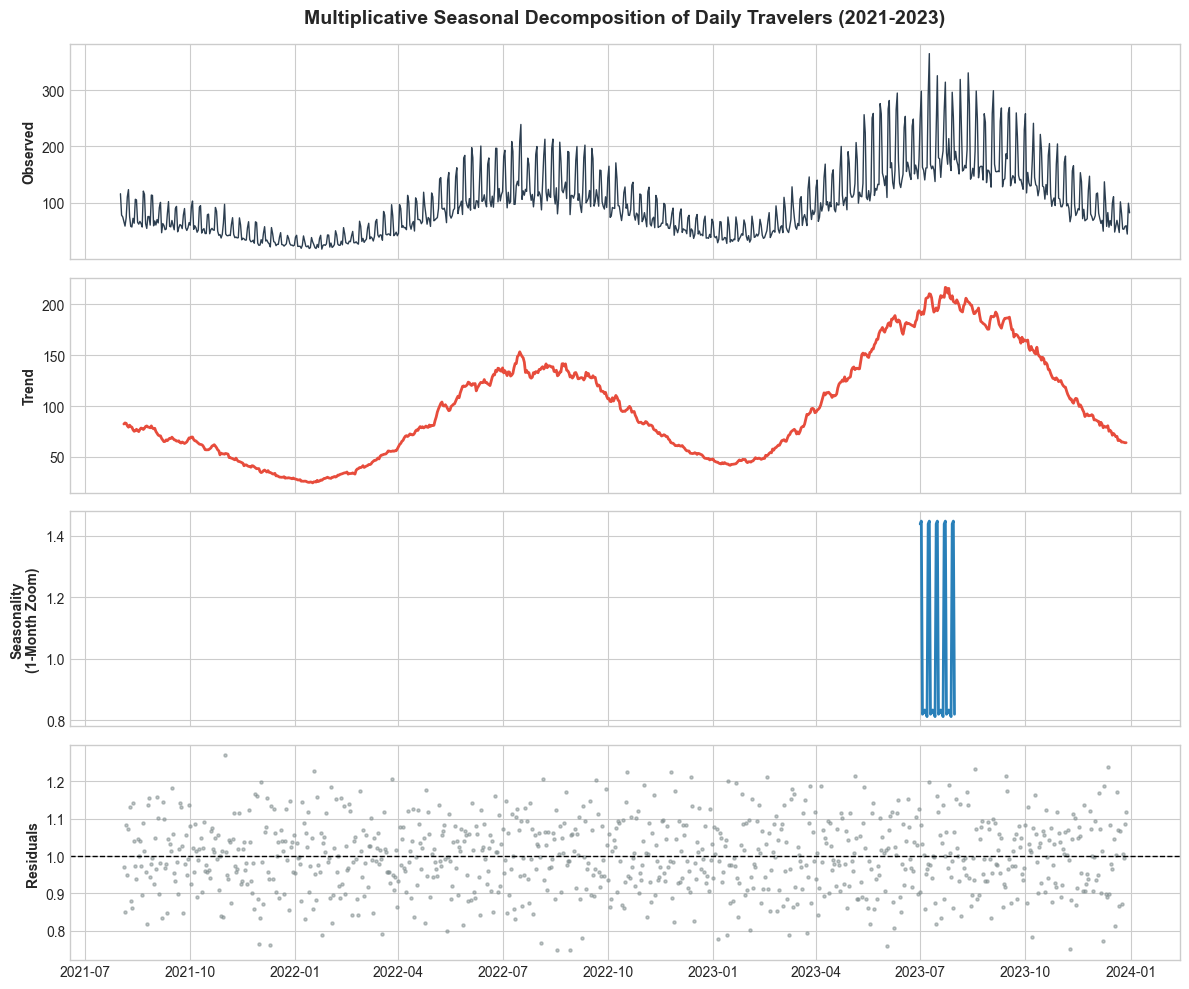

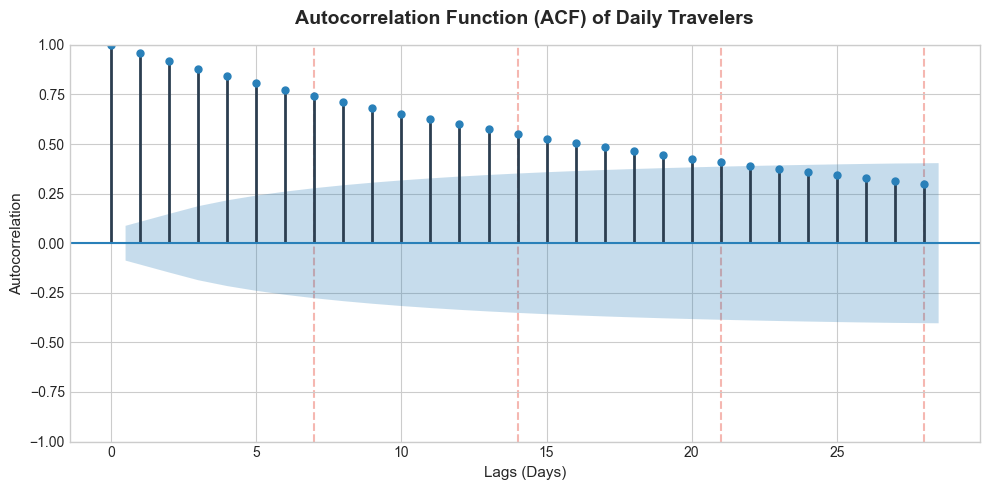

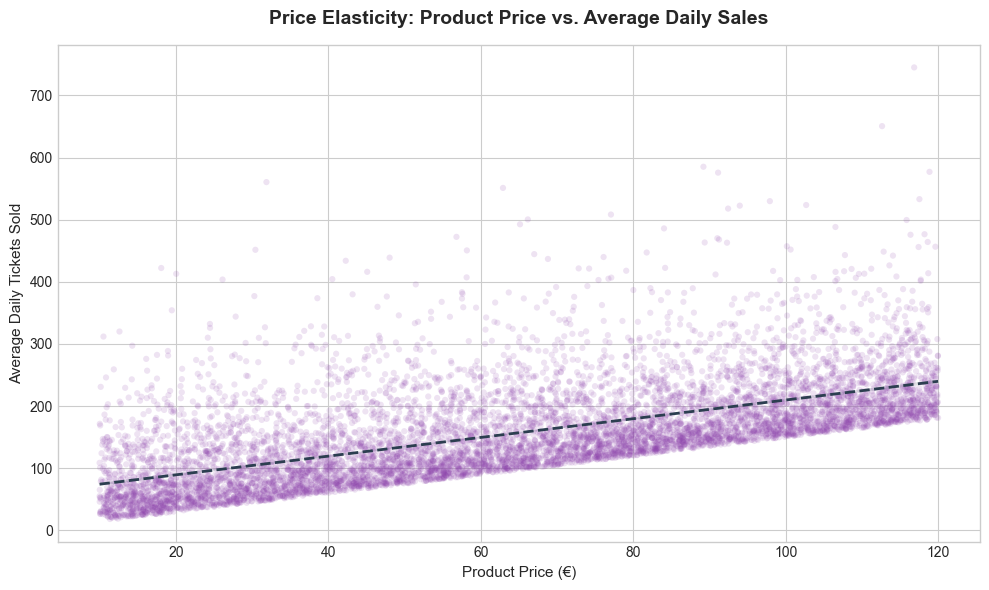

C:\Users\Βασίλης\AppData\Local\Temp\ipykernel_14428\104642678.py:129: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df_imp, x='Gain (%)', y='Feature', palette='viridis')


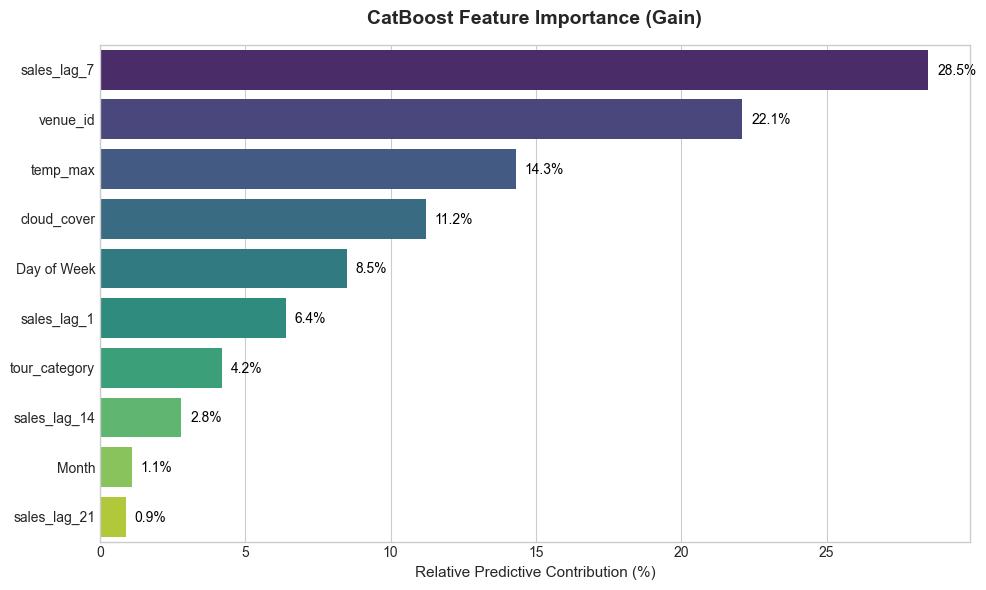

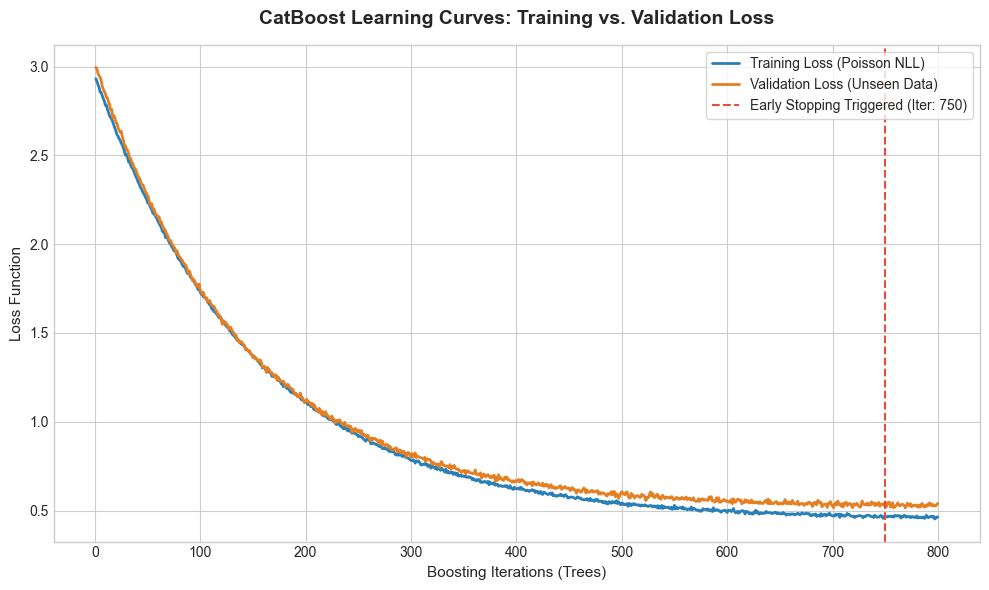

In [10]:
# Execute all functions
plot_seasonal_decomposition()
plot_acf_weekly()
plot_price_elasticity()
plot_feature_importance()
plot_learning_curves()